In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder 
from sklearn.metrics import r2_score,root_mean_squared_error
from sklearn.feature_selection import chi2
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../datasets/india_housing_prices.csv')

In [3]:
df.sample(5)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
235729,235730,Jharkhand,Ranchi,Locality_170,Independent House,1,4951,198.46,0.04,1997,...,28,4,8,High,Yes,No,"Clubhouse, Garden",East,Broker,Under_Construction
41037,41038,Haryana,Faridabad,Locality_264,Apartment,3,3212,325.60,0.10,2019,...,6,2,6,High,No,Yes,"Clubhouse, Gym, Playground, Pool",East,Broker,Ready_to_Move
126058,126059,Telangana,Warangal,Locality_235,Villa,2,796,150.28,0.19,1998,...,27,7,4,Medium,Yes,Yes,Gym,South,Broker,Under_Construction
2383,2384,Bihar,Gaya,Locality_26,Independent House,5,3771,296.49,0.08,2019,...,6,8,9,Medium,No,Yes,"Garden, Gym",East,Builder,Under_Construction
209846,209847,Assam,Silchar,Locality_133,Apartment,5,3853,69.67,0.02,1999,...,26,8,3,Low,No,No,"Gym, Clubhouse",South,Owner,Under_Construction


In [4]:
df.columns

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='str')

In [5]:
df = df.drop(columns=['ID','Locality','Facing','Availability_Status','Total_Floors','Owner_Type','State','City','Amenities'])

In [6]:
df

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security
0,Apartment,1,4740,489.76,0.10,1990,Furnished,22,35,10,3,High,No,No
1,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,17,8,1,Low,No,Yes
2,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,28,9,8,Low,Yes,No
3,Independent House,2,2741,300.29,0.11,1991,Furnished,21,34,5,7,High,Yes,Yes
4,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,23,4,9,Low,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Independent House,5,1995,274.75,0.14,1995,Furnished,19,30,8,6,Low,No,No
249996,Apartment,1,2293,13.40,0.01,2013,Semi-furnished,15,12,8,10,Low,No,No
249997,Villa,4,2910,236.94,0.08,2003,Furnished,21,22,10,4,High,Yes,Yes
249998,Villa,1,1149,141.66,0.12,2007,Unfurnished,14,18,3,7,Low,Yes,Yes


In [7]:
df.columns

Index(['Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs',
       'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No',
       'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
       'Public_Transport_Accessibility', 'Parking_Space', 'Security'],
      dtype='str')

In [8]:
df.head(5)

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security
0,Apartment,1,4740,489.76,0.10,1990,Furnished,22,35,10,3,High,No,No
1,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,17,8,1,Low,No,Yes
2,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,28,9,8,Low,Yes,No
3,Independent House,2,2741,300.29,0.11,1991,Furnished,21,34,5,7,High,Yes,Yes
4,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,23,4,9,Low,No,Yes


In [9]:
map_dict = {
    'High':2,
    'Medium':1,
    'Low':0
}

df['Public_Transport'] = df['Public_Transport_Accessibility'].map(map_dict)
df['Public_Transport']

0         2
1         0
2         0
3         2
4         0
         ..
249995    0
249996    0
249997    2
249998    0
249999    1
Name: Public_Transport, Length: 250000, dtype: int64

In [10]:
map_bool = {
    'Yes':1,
    'No':0
}

df['Parking'] = df['Parking_Space'].map(map_bool) 
df['Secure'] = df['Security'].map(map_bool)

In [11]:
df['Total_score'] = df['Parking']+df['Secure'] + df['Public_Transport']
df

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Public_Transport,Parking,Secure,Total_score
0,Apartment,1,4740,489.76,0.10,1990,Furnished,22,35,10,3,High,No,No,2,0,0,2
1,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,17,8,1,Low,No,Yes,0,0,1,1
2,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,28,9,8,Low,Yes,No,0,1,0,1
3,Independent House,2,2741,300.29,0.11,1991,Furnished,21,34,5,7,High,Yes,Yes,2,1,1,4
4,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,23,4,9,Low,No,Yes,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Independent House,5,1995,274.75,0.14,1995,Furnished,19,30,8,6,Low,No,No,0,0,0,0
249996,Apartment,1,2293,13.40,0.01,2013,Semi-furnished,15,12,8,10,Low,No,No,0,0,0,0
249997,Villa,4,2910,236.94,0.08,2003,Furnished,21,22,10,4,High,Yes,Yes,2,1,1,4
249998,Villa,1,1149,141.66,0.12,2007,Unfurnished,14,18,3,7,Low,Yes,Yes,0,1,1,2


In [12]:
furnished_map = {
    'Furnished' : '2',
    'Unfurnished' : '0',
    'Semi-furnished' : '1'
}

df['Furnished_Status_new'] = df['Furnished_Status'].map(furnished_map)
df.head(5)

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Public_Transport,Parking,Secure,Total_score,Furnished_Status_new
0,Apartment,1,4740,489.76,0.10,1990,Furnished,22,35,10,3,High,No,No,2,0,0,2,2
1,Independent House,3,2364,195.52,0.08,2008,Unfurnished,21,17,8,1,Low,No,Yes,0,0,1,1,0
2,Apartment,2,3642,183.79,0.05,1997,Semi-furnished,19,28,9,8,Low,Yes,No,0,1,0,1,1
3,Independent House,2,2741,300.29,0.11,1991,Furnished,21,34,5,7,High,Yes,Yes,2,1,1,4,2
4,Villa,4,4823,182.90,0.04,2002,Semi-furnished,3,23,4,9,Low,No,Yes,0,0,1,1,1


In [13]:
df = df.drop(columns=['Year_Built','Furnished_Status','Parking','Secure','Public_Transport','Public_Transport_Accessibility','Parking_Space','Security'])

In [14]:
df

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Total_score,Furnished_Status_new
0,Apartment,1,4740,489.76,0.10,22,35,10,3,2,2
1,Independent House,3,2364,195.52,0.08,21,17,8,1,1,0
2,Apartment,2,3642,183.79,0.05,19,28,9,8,1,1
3,Independent House,2,2741,300.29,0.11,21,34,5,7,4,2
4,Villa,4,4823,182.90,0.04,3,23,4,9,1,1
...,...,...,...,...,...,...,...,...,...,...,...
249995,Independent House,5,1995,274.75,0.14,19,30,8,6,0,2
249996,Apartment,1,2293,13.40,0.01,15,12,8,10,0,1
249997,Villa,4,2910,236.94,0.08,21,22,10,4,4,2
249998,Villa,1,1149,141.66,0.12,14,18,3,7,2,0


In [15]:
df.columns

Index(['Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs',
       'Price_per_SqFt', 'Floor_No', 'Age_of_Property', 'Nearby_Schools',
       'Nearby_Hospitals', 'Total_score', 'Furnished_Status_new'],
      dtype='str')

In [16]:
ohe = OneHotEncoder(sparse_output=False, drop= 'first')
encoded = ohe.fit_transform(df[['Property_Type']])


In [17]:
ohe.fit(df[['Property_Type']])

print(ohe.categories_)

[array(['Apartment', 'Independent House', 'Villa'], dtype=object)]


In [18]:
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(['Property_Type']))

In [19]:
df = df.merge(encoded_df,left_index=True, right_index=True)

In [20]:
df.head(5)

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Total_score,Furnished_Status_new,Property_Type_Independent House,Property_Type_Villa
0,Apartment,1,4740,489.76,0.10,22,35,10,3,2,2,0.0,0.0
1,Independent House,3,2364,195.52,0.08,21,17,8,1,1,0,1.0,0.0
2,Apartment,2,3642,183.79,0.05,19,28,9,8,1,1,0.0,0.0
3,Independent House,2,2741,300.29,0.11,21,34,5,7,4,2,1.0,0.0
4,Villa,4,4823,182.90,0.04,3,23,4,9,1,1,0.0,1.0


In [21]:
df = df.drop(columns = 'Property_Type')

In [22]:
corr = df.corr()
corr

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Total_score,Furnished_Status_new,Property_Type_Independent House,Property_Type_Villa
BHK,1.000000,-0.001033,-0.000980,0.001174,0.001263,-0.000917,-0.000762,0.001162,0.000013,-0.001264,0.001950,-0.003122
Size_in_SqFt,-0.001033,1.000000,-0.002529,-0.614533,-0.002775,-0.004135,0.001966,-0.001695,0.002027,-0.001458,-0.003914,0.003173
Price_in_Lakhs,-0.000980,-0.002529,1.000000,0.555625,-0.001719,-0.002714,0.000155,-0.002769,0.002406,-0.001544,0.003937,-0.004107
Price_per_SqFt,0.001174,-0.614533,0.555625,1.000000,-0.001906,0.001212,-0.000094,-0.000145,-0.001716,-0.000449,0.002306,-0.001743
Floor_No,0.001263,-0.002775,-0.001719,-0.001906,1.000000,0.000686,-0.000635,0.001428,-0.001958,-0.000330,-0.000838,-0.000577
Age_of_Property,-0.000917,-0.004135,-0.002714,0.001212,0.000686,1.000000,0.000591,0.002719,-0.002567,0.002546,0.001233,0.001165
Nearby_Schools,-0.000762,0.001966,0.000155,-0.000094,-0.000635,0.000591,1.000000,-0.002246,-0.002229,-0.002473,-0.000128,0.001383
Nearby_Hospitals,0.001162,-0.001695,-0.002769,-0.000145,0.001428,0.002719,-0.002246,1.000000,0.000598,-0.000393,0.003789,0.002730
Total_score,0.000013,0.002027,0.002406,-0.001716,-0.001958,-0.002567,-0.002229,0.000598,1.000000,-0.001305,0.000471,0.001872
Furnished_Status_new,-0.001264,-0.001458,-0.001544,-0.000449,-0.000330,0.002546,-0.002473,-0.000393,-0.001305,1.000000,0.000502,-0.002609


<Axes: >

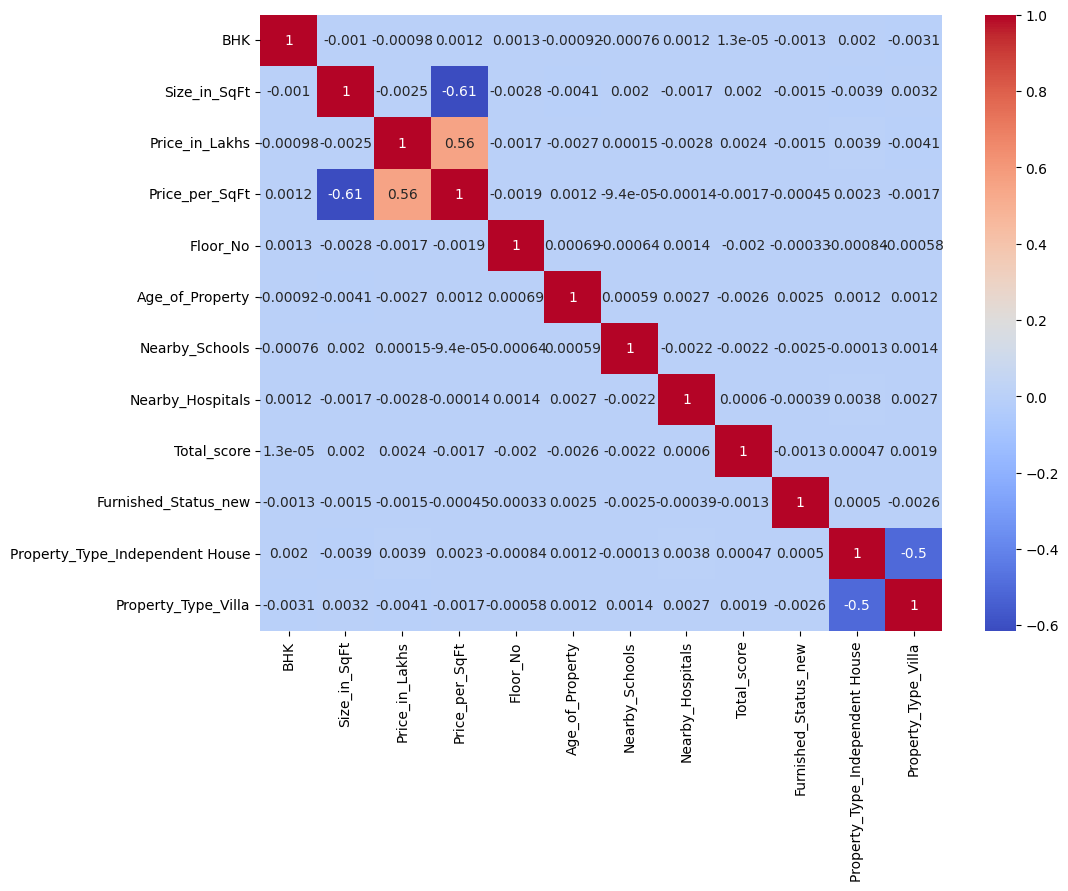

In [23]:
plt.figure(figsize=(11,8))

sns.heatmap(corr, annot=True, cmap= 'coolwarm')

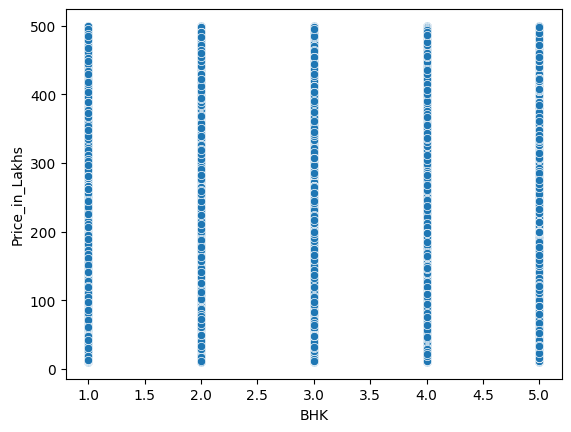

In [24]:
sns.scatterplot(
    x='BHK',
    y='Price_in_Lakhs',
    data=df
)
plt.show()

In [25]:
corr['Price_in_Lakhs'].sort_values(ascending=False)

Price_in_Lakhs                     1.000000
Price_per_SqFt                     0.555625
Property_Type_Independent House    0.003937
Total_score                        0.002406
Nearby_Schools                     0.000155
BHK                               -0.000980
Furnished_Status_new              -0.001544
Floor_No                          -0.001719
Size_in_SqFt                      -0.002529
Age_of_Property                   -0.002714
Nearby_Hospitals                  -0.002769
Property_Type_Villa               -0.004107
Name: Price_in_Lakhs, dtype: float64

In [26]:
df['PPS'] = df['Size_in_SqFt'] * df['Price_per_SqFt']
# df['Square_PPS'] = (df['Size_in_SqFt'] ** 2) * (df['Price_per_SqFt']**2)

In [27]:
df = df.drop(columns=['Size_in_SqFt','Price_per_SqFt'])

In [28]:
# log target column
df['Price_in_Lakhs'] = np.log1p(df['Price_in_Lakhs'])

In [29]:
X = df.drop(columns=['Price_in_Lakhs'])
y = df['Price_in_Lakhs']


In [30]:
X

,BHK,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Total_score,Furnished_Status_new,Property_Type_Independent House,Property_Type_Villa,PPS
0,1,22,35,10,3,2,2,0.0,0.0,474.00
1,3,21,17,8,1,1,0,1.0,0.0,189.12
2,2,19,28,9,8,1,1,0.0,0.0,182.10
3,2,21,34,5,7,4,2,1.0,0.0,301.51
4,4,3,23,4,9,1,1,0.0,1.0,192.92
...,...,...,...,...,...,...,...,...,...,...
249995,5,19,30,8,6,0,2,1.0,0.0,279.30
249996,1,15,12,8,10,0,1,0.0,0.0,22.93
249997,4,21,22,10,4,4,2,0.0,1.0,232.80
249998,1,14,18,3,7,2,0,0.0,1.0,137.88


In [31]:
y

0         6.195955
1         5.280764
2         5.219220
3         5.708073
4         5.214392
            ...   
249995    5.619495
249996    2.667228
249997    5.472019
249998    4.960464
249999    5.301761
Name: Price_in_Lakhs, Length: 250000, dtype: float64

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled

,BHK,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Total_score,Furnished_Status_new,Property_Type_Independent House,Property_Type_Villa,PPS
75381,1.413250,-0.776763,1.071034,-1.215645,-1.217845,-1.850207,0.000557,-0.707316,-0.710198,-1.501425
65569,-0.705799,-0.441361,-1.373369,1.563139,0.175788,-0.924731,0.000557,-0.707316,1.408058,-1.468811
163473,-1.412149,-1.559368,1.478435,1.215791,0.524196,-0.924731,1.225240,-0.707316,-0.710198,0.114501
90518,-1.412149,1.123848,-1.373369,0.173747,0.524196,-1.850207,-1.224125,-0.707316,1.408058,-0.873790
138866,-0.705799,-1.335767,1.478435,1.215791,-0.521029,0.926221,1.225240,-0.707316,1.408058,-1.486600
...,...,...,...,...,...,...,...,...,...,...
119879,0.706901,0.676646,-1.373369,-0.520949,-0.172621,0.926221,0.000557,-0.707316,-0.710198,1.017375
103694,-1.412149,0.005842,-0.049317,0.868443,-1.566253,-0.924731,0.000557,-0.707316,1.408058,-1.063965
131932,-1.412149,-1.000365,-1.577069,0.868443,1.221012,-0.924731,1.225240,-0.707316,-0.710198,-0.121418
146867,-1.412149,-0.441361,-0.660418,-1.215645,0.524196,-0.924731,0.000557,1.413795,-0.710198,-1.460199


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly_train = poly.fit_transform(X_train_scaled[['PPS']])
X_poly_test = poly.transform(X_test_scaled[['PPS']])
print(type(X_poly_train))


<class 'numpy.ndarray'>


In [38]:
poly_train_df = pd.DataFrame(
    X_poly_train,
    columns=poly.get_feature_names_out(['PPS']),
    index=X_train_scaled.index
)

poly_test_df = pd.DataFrame(
    X_poly_test,
    columns=poly.get_feature_names_out(['PPS']),
    index=X_test_scaled.index
)

In [39]:
X_train_final = X_train_scaled.drop('PPS', axis=1)
X_test_final = X_test_scaled.drop('PPS', axis=1)

In [40]:
X_train_final = pd.concat([X_train_final, poly_train_df], axis=1)
X_test_final = pd.concat([X_test_final, poly_test_df], axis=1)

In [44]:
model = LinearRegression()
model.fit(X_train_final, y_train)

y_pred_log = model.predict(X_test_final)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("R2 score on original y ", r2_score(y_true, y_pred))
print("R2 Score after log:", r2_score(y_test, y_pred_log))

R2 score on original y  0.957232435681358
R2 Score after log: 0.9574906255124063


In [ ]:
# print(r2_score(y_train, model.predict(X_poly_train)))
# print(r2_score(y_test, model.predict(X_poly_test)))